# Dimensionality Reduction



1. Feature Selection
2. Feature Extraction





## Feature Selection (Filter-based Methods)



### Using Correlation Coefficients

If two features are highly correlated, they likely convey similar information. Removing one of them helps reduce data redundancy, prevent multicollinearity in models, and simplify the dataset without significant information loss.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate a new synthetic dataset with inter-feature correlations
new_num_samples = 150 # Slightly different number of samples

# Create some base features
base_A = np.random.rand(new_num_samples) * 20
base_B = np.random.rand(new_num_samples) * 10

new_data = {
    'feature_X': base_A + np.random.normal(0, 1.5, new_num_samples), # Highly correlated with Y
    'feature_Y': base_A * 0.9 + np.random.normal(0, 1, new_num_samples),  # Highly correlated with X
    'feature_Z': base_B * 1.5 + np.random.normal(0, 2, new_num_samples), # Highly correlated with W
    'feature_W': base_B + np.random.normal(0, 1, new_num_samples),      # Highly correlated with Z
    'feature_P': np.random.rand(new_num_samples) * 5,   # Low correlation
    'feature_Q': np.random.rand(new_num_samples) * 7    # Low correlation
}

df = pd.DataFrame(new_data)

print("Original DataFrame head with inter-correlated features for the new example:")
display(df.head())

Original DataFrame head with inter-correlated features for the new example:


,feature_X,feature_Y,feature_Z,feature_W,feature_P,feature_Q
0,9.870809,8.493700,8.614441,6.499612,0.205941,5.798145
1,5.456723,4.222539,11.376387,6.077971,2.998001,3.376876
2,3.345815,1.420458,14.943405,7.933537,0.612222,1.241441
3,19.216955,16.368556,6.545114,5.018715,2.110710,6.436144
4,17.683473,16.713523,1.756818,0.762811,3.168348,2.597010


First, we'll compute the correlation matrix for all features in our new synthetic dataset. This matrix quantifies the linear relationship between every possible pair of features.

In [2]:
# Calculate the correlation matrix for all features in the new dataset
correlation_matrix = df.corr()

print("Inter-feature Correlation Matrix for the new example:")
display(correlation_matrix)

Inter-feature Correlation Matrix for the new example:


,feature_X,feature_Y,feature_Z,feature_W,feature_P,feature_Q
feature_X,1.000000,0.953627,-0.057929,-0.086269,-0.110846,0.052497
feature_Y,0.953627,1.000000,-0.080905,-0.117520,-0.082576,0.018847
feature_Z,-0.057929,-0.080905,1.000000,0.877636,0.153812,-0.000162
feature_W,-0.086269,-0.117520,0.877636,1.000000,0.208059,-0.008337
feature_P,-0.110846,-0.082576,0.153812,0.208059,1.000000,-0.142172
feature_Q,0.052497,0.018847,-0.000162,-0.008337,-0.142172,1.000000


A heatmap provides an intuitive visual representation of these correlations, allowing for quick identification of highly related features and patterns.

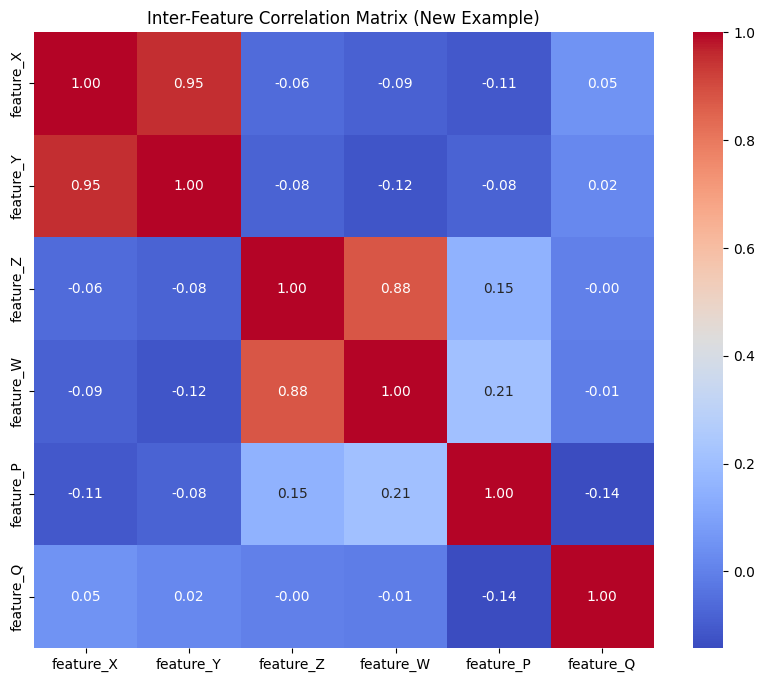

In [3]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Inter-Feature Correlation Matrix (New Example)')
plt.show()

To perform dimensionality reduction, we'll establish an absolute correlation threshold. We'll then iterate through the correlation matrix, identify pairs of features whose absolute correlation exceeds this threshold, and remove one feature from each highly correlated pair.

In this new synthetic dataset, we expect `feature_X` and `feature_Y` to be highly correlated, and similarly, `feature_Z` and `feature_W` to be highly correlated, based on how we constructed them. Features `P` and `Q` should show low correlation with others.

In [4]:
correlation_threshold = 0.85 # Define a new threshold for high correlation

# Create a set to store features to be dropped
new_features_to_drop = set()

# Get the absolute correlation matrix for the new dataset
abs_corr_matrix_new = correlation_matrix.abs()

# Iterate through the upper triangle of the correlation matrix to find highly correlated pairs
for i in range(len(abs_corr_matrix_new.columns)):
    for j in range(i):
        if abs_corr_matrix_new.iloc[i, j] > correlation_threshold:
            colname_i = abs_corr_matrix_new.columns[i]
            colname_j = abs_corr_matrix_new.columns[j]

            # For simplicity, we'll drop one of the features from the pair.
            # A more sophisticated approach might use other criteria to decide which to drop.
            if colname_j not in new_features_to_drop: # Ensure we don't try to drop a feature twice
                new_features_to_drop.add(colname_i)
                print(f"Identified highly correlated pair: ({colname_i}, {colname_j}) with correlation {correlation_matrix.iloc[i, j]:.2f}. Marking {colname_i} for removal.")

# Create a new DataFrame without the identified features
df_reduced = df.drop(columns=list(new_features_to_drop))

print(f"\nFeatures to drop based on correlation threshold {correlation_threshold}: {list(new_features_to_drop)}")
print("\nDataFrame with reduced features head (new unsupervised example):")
display(df_reduced.head())

print(f"Original number of features: {len(df.columns)}")
print(f"Reduced number of features: {len(df_reduced.columns)}")

Identified highly correlated pair: (feature_Y, feature_X) with correlation 0.95. Marking feature_Y for removal.
Identified highly correlated pair: (feature_W, feature_Z) with correlation 0.88. Marking feature_W for removal.

Features to drop based on correlation threshold 0.85: ['feature_Y', 'feature_W']

DataFrame with reduced features head (new unsupervised example):


,feature_X,feature_Z,feature_P,feature_Q
0,9.870809,8.614441,0.205941,5.798145
1,5.456723,11.376387,2.998001,3.376876
2,3.345815,14.943405,0.612222,1.241441
3,19.216955,6.545114,2.110710,6.436144
4,17.683473,1.756818,3.168348,2.597010


Original number of features: 6
Reduced number of features: 4


### Using Variance Threshold

Variance Thresholding is a baseline approach to feature selection. It removes features whose variance is less than a certain threshold. Features with very low variance are almost constant across all samples, meaning they don't contribute much to the predictive power of a model and can be safely removed without significant information loss. This is an unsupervised method as it doesn't consider the target variable.

In [5]:
from sklearn.feature_selection import VarianceThreshold

# Using the original DataFrame 'df' from the previous example for consistency
# If you wish to use df_new_unsupervised, please change 'df' to 'df_new_unsupervised'

print("Original DataFrame head for Variance Thresholding:")
display(df.head())

print("\nVariances of original features:")
print(df.var())

Original DataFrame head for Variance Thresholding:


,feature_X,feature_Y,feature_Z,feature_W,feature_P,feature_Q
0,9.870809,8.493700,8.614441,6.499612,0.205941,5.798145
1,5.456723,4.222539,11.376387,6.077971,2.998001,3.376876
2,3.345815,1.420458,14.943405,7.933537,0.612222,1.241441
3,19.216955,16.368556,6.545114,5.018715,2.110710,6.436144
4,17.683473,16.713523,1.756818,0.762811,3.168348,2.597010



Variances of original features:
feature_X    33.850567
feature_Y    28.322486
feature_Z    26.557451
feature_W     9.367869
feature_P     2.146338
feature_Q     4.447624
dtype: float64


Now, we'll apply the `VarianceThreshold` transformer. We'll set a threshold, and any feature with a variance below this threshold will be removed. For demonstration, we'll use a threshold to remove features that are almost constant.

In [6]:
variance_threshold = 5.0 # Define a variance threshold

# Initialize VarianceThreshold with the chosen threshold
selector = VarianceThreshold(threshold=variance_threshold)

# Fit and transform the data
# Note: VarianceThreshold expects a NumPy array, so we pass df.values
# We also need to get the feature names back after transformation
df_high_variance_features = selector.fit_transform(df)

# Get the names of the selected features
selected_feature_indices = selector.get_support(indices=True)
selected_feature_names = df.columns[selected_feature_indices].tolist()

# Create a new DataFrame with only the selected features
df_reduced_by_variance = pd.DataFrame(df_high_variance_features, columns=selected_feature_names)

print(f"Features selected based on variance threshold > {variance_threshold}:")
print(selected_feature_names)

print("\nDataFrame with reduced features head (Variance Thresholding):")
display(df_reduced_by_variance.head())

print(f"Original number of features: {df.shape[1]}")
print(f"Reduced number of features: {df_reduced_by_variance.shape[1]}")

Features selected based on variance threshold > 5.0:
['feature_X', 'feature_Y', 'feature_Z', 'feature_W']

DataFrame with reduced features head (Variance Thresholding):


,feature_X,feature_Y,feature_Z,feature_W
0,9.870809,8.493700,8.614441,6.499612
1,5.456723,4.222539,11.376387,6.077971
2,3.345815,1.420458,14.943405,7.933537
3,19.216955,16.368556,6.545114,5.018715
4,17.683473,16.713523,1.756818,0.762811


Original number of features: 6
Reduced number of features: 4


## Feature Extraction (PCA)

In [7]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Create 100 rows of data with 10 features
np.random.seed(42)
data = np.random.rand(100, 10)
df = pd.DataFrame(data, columns=[f'Feature_{i+1}' for i in range(10)])

# 2. Standardize
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# 3. Apply PCA (asking for all 10 components first to see the spread)
pca = PCA(n_components=10)
pca_data = pca.fit_transform(scaled_data)

# 4. Check the "Information Content"
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Variance explained by PC1: {explained_variance[0]:.2%}")
print(f"Total variance explained by first 2 PCs: {cumulative_variance[1]:.2%}")

Variance explained by PC1: 15.71%
Total variance explained by first 2 PCs: 29.28%


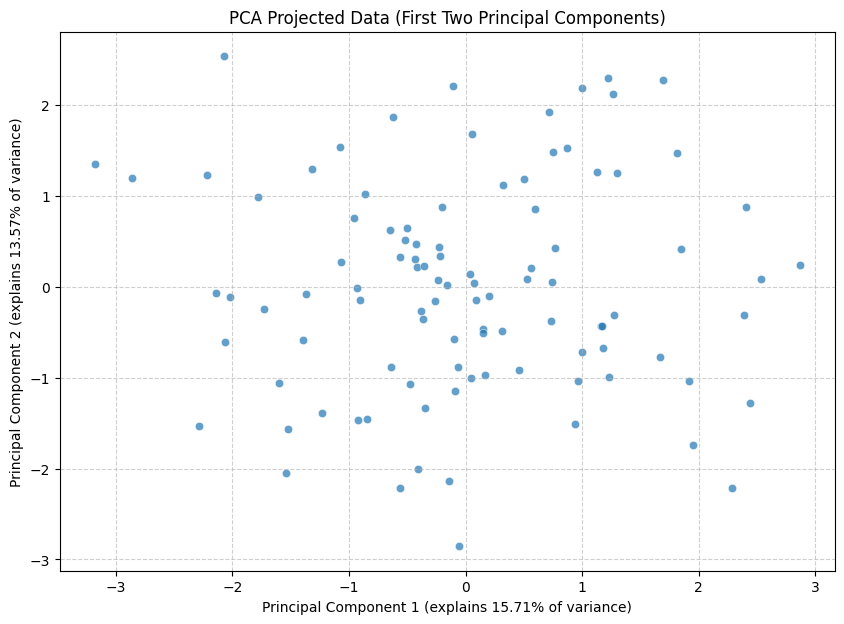

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for the PCA-transformed data to make plotting easier
pca_df = pd.DataFrame(pca_data, columns=[f'PC_{i+1}' for i in range(pca_data.shape[1])])

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC_1', y='PC_2', data=pca_df, alpha=0.7)
plt.title('PCA Projected Data (First Two Principal Components)')
plt.xlabel(f'Principal Component 1 (explains {explained_variance[0]*100:.2f}% of variance)')
plt.ylabel(f'Principal Component 2 (explains {explained_variance[1]*100:.2f}% of variance)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

This scatter plot visualizes the dataset in a 2-dimensional space, where the axes are the first two principal components (PC1 and PC2). These two components capture the most variance in the original 10-dimensional data. Each point represents an original data sample, now projected onto this new, lower-dimensional subspace. The plot helps to identify any clusters, patterns, or outliers that might exist in the data, which were less visible in the higher-dimensional space.